# TAPAS privacy analysis

Five outputs at each of four audit sizes: 50/100, 200/500, 500/1000, 1000/2500 (num_train/num_test).

1. Raw score distributions, member vs non-member
2. Mann-Whitney U test on those scores
3. Classification metrics and effective epsilon with 95% bounds
4. MIA AUC against the null band
5. Privacy-utility tradeoff

Source: `results/counts_sweep/`, generated by `scripts/run_counts_sweep.py` (per-fit generator
seeding, `seeds.TAPAS_GENERATOR_SEED_BASE + i`).

In [43]:
from pathlib import Path
import sys, glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import gaussian_kde, mannwhitneyu

_cwd = Path.cwd()
BENCH = next(c for c in (_cwd, _cwd / "benchmark_tapas", _cwd.parent) if (c / "config.py").exists())
sys.path.insert(0, str(BENCH))
from config import METHODS, METHOD_CONFIG, FIGURES_DIR, UTILITY_RESULTS

SWEEP = BENCH / "results" / "counts_sweep"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

STAGES = [(50, 100), (200, 500), (500, 1000), (1000, 2500)]
ORANGE, CHARCOAL, SAGE, ROSE = "#CE4E36", "#3A3A3A", "#8CA9A0", "#D2B4B1"
INK, MUTED, GRID = "#3A3A3A", "#6B6B6B", "#DDDDDD"
GEN_COLOR = {"bayesian_network": ORANGE, "privbayes": CHARCOAL, "ctgan": SAGE, "dpgan": ROSE}
LABELS = {"bayesian_network": "BN (no-DP)", "privbayes": "PrivBayes (DP)",
          "ctgan": "CTGAN (no-DP)", "dpgan": "DPGAN (DP)"}
SHORT = {"bayesian_network": "BN", "privbayes": "PrivBayes",
         "ctgan": "CTGAN", "dpgan": "DPGAN"}
ATTACK_ORDER = ["Groundhog", "ShadowModelling", "LocalNeighbourhood",
                "ProbabilityEstimation", "ClosestDistance"]
SHORT_ATK = {"Groundhog": "Groundhog", "ShadowModelling": "ShadowMod.",
             "LocalNeighbourhood": "LocalNbr.", "ProbabilityEstimation": "ProbabilityEst.",
             "ClosestDistance": "ClosestDist."}
SCORE_LABEL = {"Groundhog": "RF P(member)", "ShadowModelling": "RF P(member)",
               "LocalNeighbourhood": "fraction of records in radius",
               "ProbabilityEstimation": "KDE log-density at target",
               "ClosestDistance": "negative min L2 distance"}
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 200,
                     "savefig.facecolor": "white", "font.size": 10})


def null_halfwidth(n1, n2):
    """Half-width of the 95% band around AUC=0.5 under H0. Depends on num_test, so it
    is recomputed at every stage: +-0.114 at num_test=100 down to +-0.023 at 2500."""
    return 1.96 * np.sqrt((n1 + n2 + 1) / (12 * n1 * n2))


def density(v, grid):
    v = np.asarray(v)
    if len(np.unique(v)) < 3 or np.std(v) == 0:
        return None
    try:
        return gaussian_kde(v)(grid)
    except np.linalg.LinAlgError:
        return None


def tidy(ax):
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color(GRID)
    ax.tick_params(colors=MUTED, labelsize=8, length=3)
    ax.set_axisbelow(True)


# ---- load every stage ----
SCORES, METRICS = {}, {}
for ntr, nte in STAGES:
    st = f"{ntr}_{nte}"
    s = [pd.read_csv(f) for f in sorted(glob.glob(str(SWEEP / f"raw_scores_*_{st}.csv")))]
    m = [pd.read_csv(f) for f in sorted(glob.glob(str(SWEEP / "*" / st / f"effeps_*_{st}.csv")))]
    if not s or not m:
        continue
    sd = pd.concat(s, ignore_index=True); sd["attack_short"] = sd.attack.str.split("(").str[0]
    md_ = pd.concat(m, ignore_index=True); md_["attack_short"] = md_.attack.str.split("(").str[0]
    SCORES[st], METRICS[st] = sd, md_

AVAIL = [(a, b) for a, b in STAGES if f"{a}_{b}" in SCORES]
GENS = [g for g in METHODS if g in set(SCORES[f"{AVAIL[0][0]}_{AVAIL[0][1]}"].generator)]
BANDS = {f"{a}_{b}": null_halfwidth(b // 2, b // 2) for a, b in AVAIL}

for a, b in AVAIL:
    st = f"{a}_{b}"
    print(f"{st:>10}: {len(SCORES[st]):6,} score rows | {SCORES[st].generator.nunique()} generators "
          f"| null band +-{BANDS[st]:.3f}")

    50_100:  2,000 score rows | 4 generators | null band +-0.114
   200_500: 10,000 score rows | 4 generators | null band +-0.051
  500_1000: 20,000 score rows | 4 generators | null band +-0.036
 1000_2500: 50,000 score rows | 4 generators | null band +-0.023


## 1. Raw score distributions

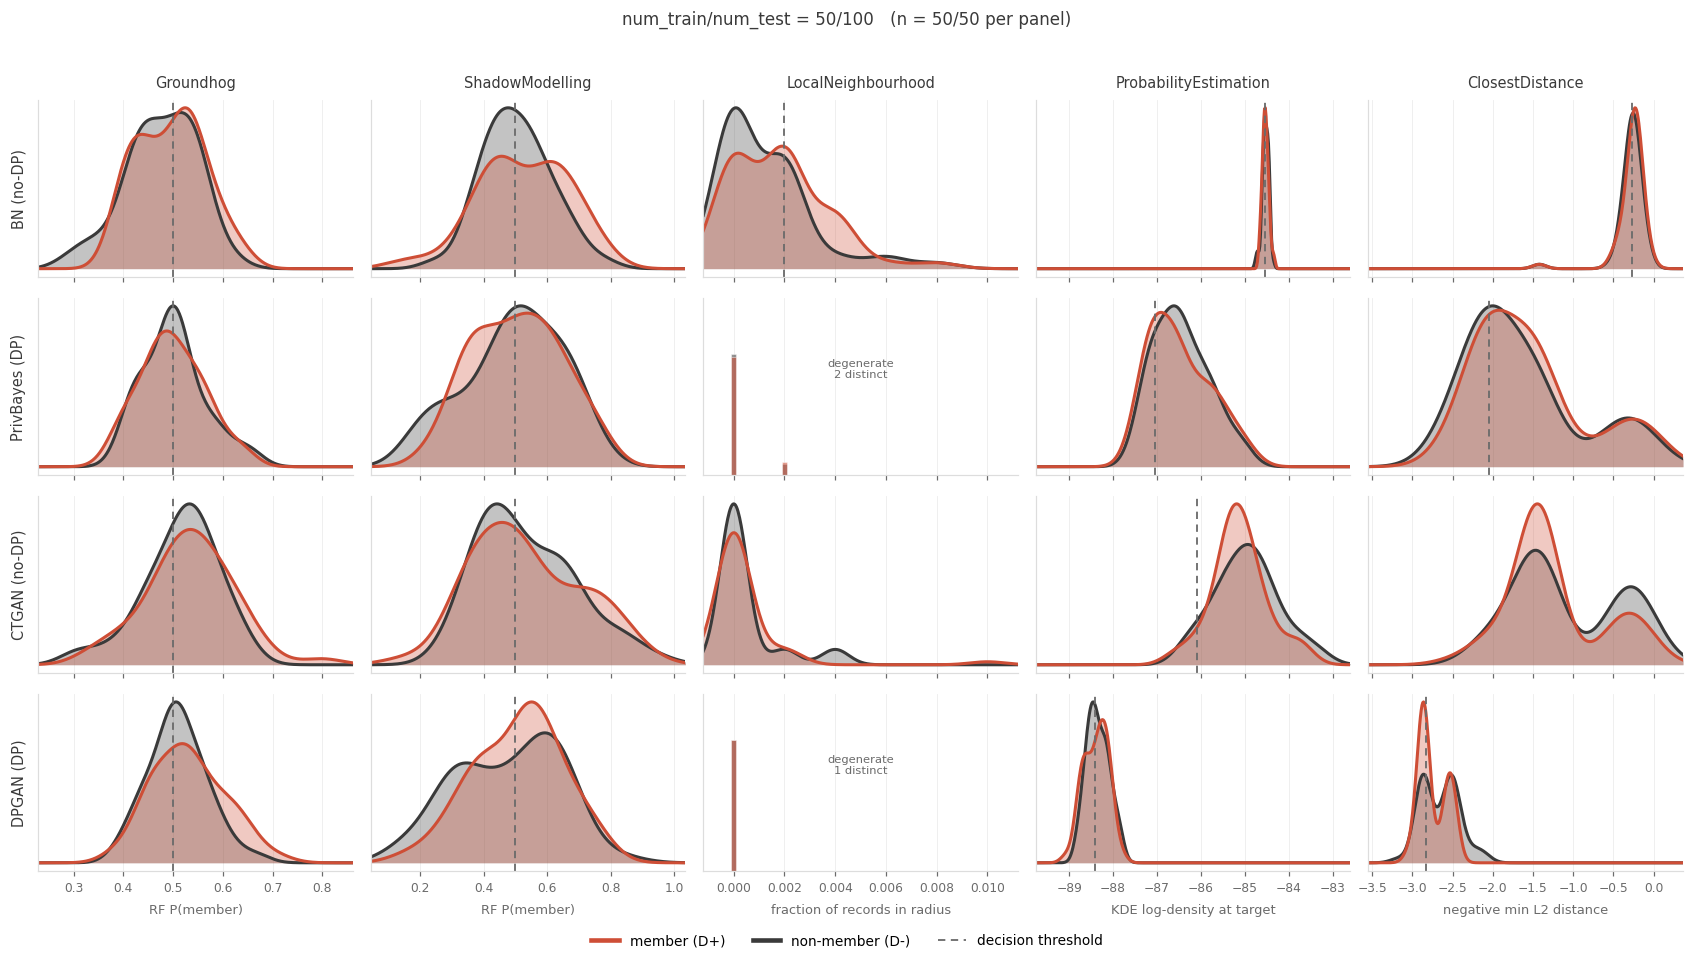

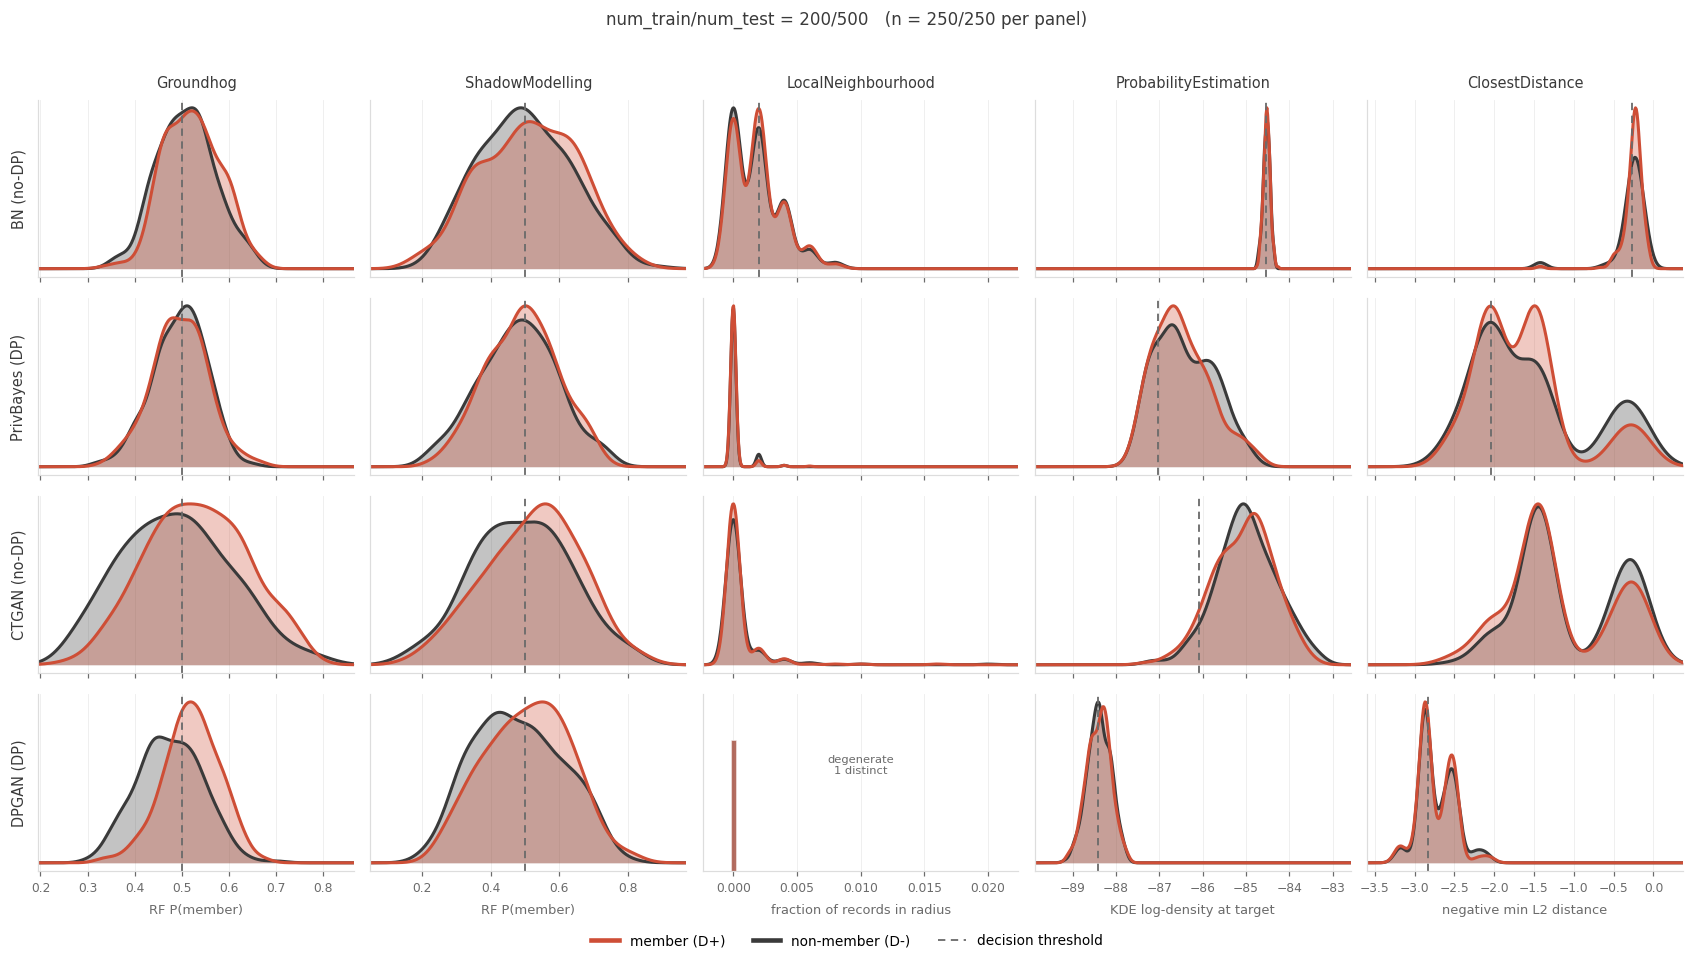

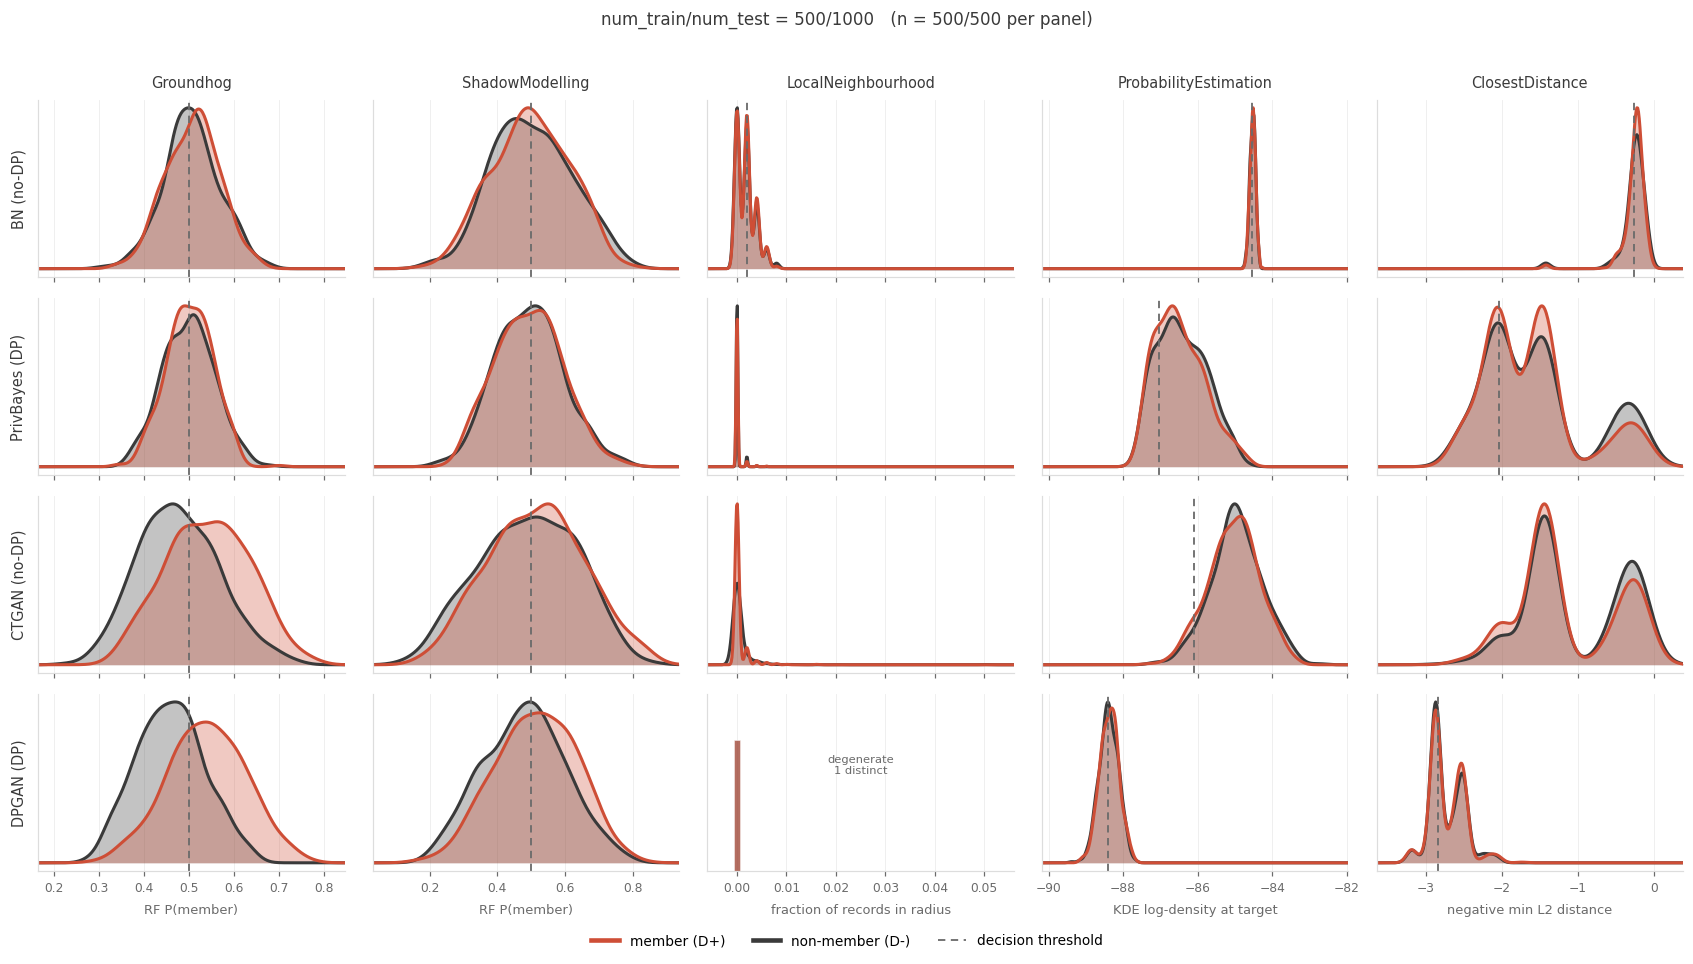

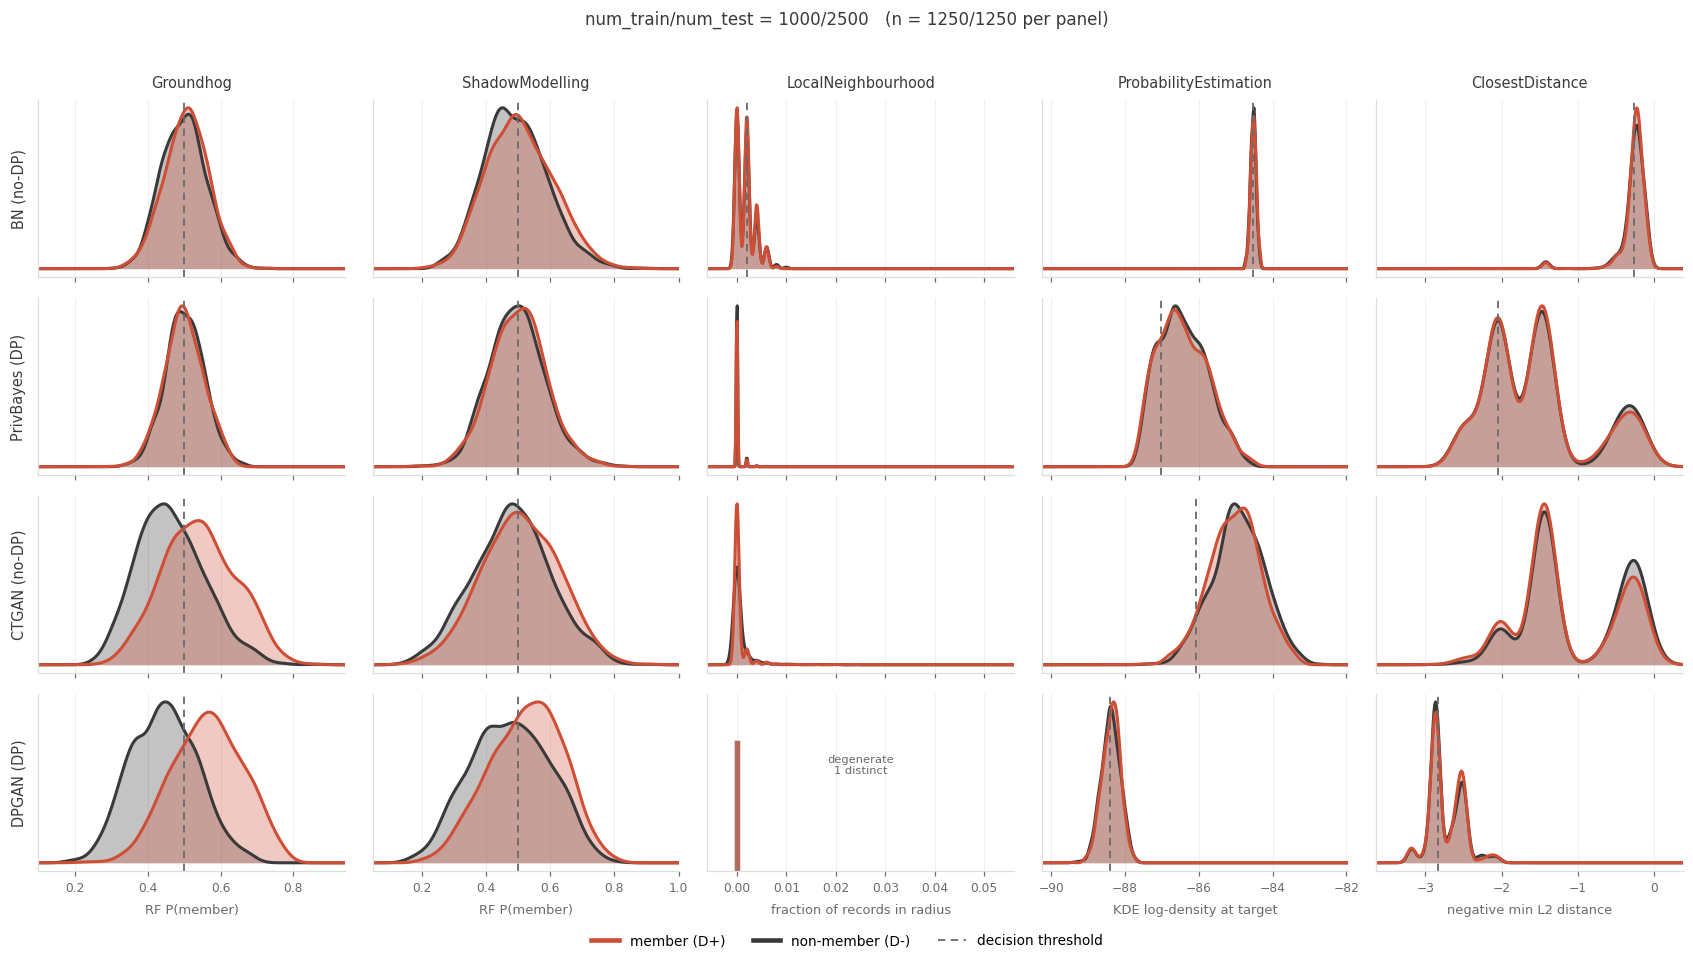

In [44]:
for ntr, nte in AVAIL:
    st = f"{ntr}_{nte}"
    sc = SCORES[st]
    attacks = [a for a in ATTACK_ORDER if a in set(sc.attack_short)]
    fig, axes = plt.subplots(len(GENS), len(attacks), sharex="col",
                             figsize=(3.1 * len(attacks), 2.15 * len(GENS)), squeeze=False)
    for c, atk in enumerate(attacks):
        sub = sc[sc.attack_short == atk]
        lo, hi = sub.raw_score.min(), sub.raw_score.max()
        pad = (hi - lo) * 0.12 if hi > lo else 0.5
        grid = np.linspace(lo - pad, hi + pad, 400)
        for r, gen in enumerate(GENS):
            ax = axes[r][c]
            g = sub[sub.generator == gen]
            mem = g[g.ground_truth == 1].raw_score.values
            non = g[g.ground_truth == 0].raw_score.values
            dm, dn = density(mem, grid), density(non, grid)
            if dm is None or dn is None:
                w = (grid[-1] - grid[0]) / 60
                for vals, col in ((non, CHARCOAL), (mem, ORANGE)):
                    u, cts = np.unique(vals, return_counts=True)
                    ax.bar(u, cts / cts.sum(), width=w, color=col, alpha=.55,
                           edgecolor="white", lw=.5)
                ax.set_ylim(0, 1.35)
                ax.text(.5, .55, f"degenerate\n{g.raw_score.nunique()} distinct",
                        transform=ax.transAxes, ha="center", fontsize=7.5, color=MUTED)
            else:
                ax.fill_between(grid, dn, color=CHARCOAL, alpha=.30, lw=0)
                ax.fill_between(grid, dm, color=ORANGE, alpha=.30, lw=0)
                ax.plot(grid, dn, color=CHARCOAL, lw=2)
                ax.plot(grid, dm, color=ORANGE, lw=2)
            thr = g.threshold.iloc[0]
            if np.isfinite(thr) and grid[0] <= thr <= grid[-1]:
                ax.axvline(thr, color=MUTED, ls=(0, (4, 3)), lw=1.2)
            ax.set_xlim(grid[0], grid[-1]); ax.set_yticks([]); tidy(ax)
            ax.grid(axis="x", color=GRID, lw=.6, alpha=.5)
            if r == 0: ax.set_title(atk, fontsize=9.5, color=INK, pad=8)
            if c == 0: ax.set_ylabel(LABELS[gen], fontsize=9.5, color=INK, labelpad=8)
            if r == len(GENS) - 1:
                ax.set_xlabel(SCORE_LABEL.get(atk, "score"), fontsize=8.5, color=MUTED, labelpad=6)
    fig.legend(handles=[Line2D([], [], color=ORANGE, lw=3, label="member (D+)"),
                        Line2D([], [], color=CHARCOAL, lw=3, label="non-member (D-)"),
                        Line2D([], [], color=MUTED, ls=(0, (4, 3)), lw=1.2, label="decision threshold")],
               loc="lower center", ncol=3, frameon=False, fontsize=9, bbox_to_anchor=(.5, -.004))
    fig.suptitle(f"num_train/num_test = {ntr}/{nte}   (n = {nte//2}/{nte//2} per panel)",
                 fontsize=11, color=INK, y=1.0)
    fig.tight_layout(rect=[0, .025, 1, .985])
    fig.savefig(FIGURES_DIR / f"separation_{st}.png", bbox_inches="tight")
    plt.show()

## 2. Mann-Whitney U test

Two-sided, tie-corrected. H0: member and non-member raw scores share a distribution.

In [45]:
ALPHA = 0.05
MW = {}
for ntr, nte in AVAIL:
    st = f"{ntr}_{nte}"; sc = SCORES[st]
    rows = []
    for gen in GENS:
        for atk in [a for a in ATTACK_ORDER if a in set(sc.attack_short)]:
            cell = sc[(sc.generator == gen) & (sc.attack_short == atk)]
            m = cell[cell.ground_truth == 1].raw_score.values
            n = cell[cell.ground_truth == 0].raw_score.values
            U, p = mannwhitneyu(m, n, alternative="two-sided")
            rows.append(dict(generator=SHORT[gen], attack=atk, p=p, auc=U / (len(m) * len(n))))
    MW[st] = pd.DataFrame(rows)
    tbl = MW[st].pivot(index="generator", columns="attack", values="p")
    tbl = tbl.reindex(index=[SHORT[g] for g in GENS],
                      columns=[a for a in ATTACK_ORDER if a in tbl.columns])
    n_sig = int((MW[st].p < ALPHA).sum())
    print(f"\n=== {ntr}/{nte} ===   significant at p<{ALPHA}: {n_sig} of {len(MW[st])}"
          f"   (Bonferroni {ALPHA}/{len(MW[st])} = {ALPHA/len(MW[st]):.4f}: "
          f"{int((MW[st].p < ALPHA/len(MW[st])).sum())})")
    print(tbl.round(4).to_string())


=== 50/100 ===   significant at p<0.05: 0 of 20   (Bonferroni 0.05/20 = 0.0025: 0)
attack     Groundhog  ShadowModelling  LocalNeighbourhood  ProbabilityEstimation  ClosestDistance
generator                                                                                        
BN            0.3167           0.3643              0.0752                 0.5510           0.1733
PrivBayes     0.8063           0.9203              0.7333                 0.6867           0.5015
CTGAN         0.3374           0.9368              0.5255                 0.2344           0.5789
DPGAN         0.1500           0.4317              1.0000                 0.6124           0.0515

=== 200/500 ===   significant at p<0.05: 5 of 20   (Bonferroni 0.05/20 = 0.0025: 2)
attack     Groundhog  ShadowModelling  LocalNeighbourhood  ProbabilityEstimation  ClosestDistance
generator                                                                                        
BN            0.0271           0.2250          

## 3. Classification metrics and effective epsilon

In [46]:
COLS = ["auc", "tp", "fp", "mia_advantage", "privacy_gain",
        "eff_epsilon_pointwise", "eps_low_95", "eps_high_95"]
for ntr, nte in AVAIL:
    st = f"{ntr}_{nte}"; m = METRICS[st].copy()
    m["generator"] = m.method.map(SHORT)
    m = m.sort_values(["method", "attack_short"],
                      key=lambda s: s.map({g: i for i, g in enumerate(GENS)}) if s.name == "method" else s)
    out = m[["generator", "attack_short"] + [c for c in COLS if c in m]]
    out = out.rename(columns={"attack_short": "attack", "mia_advantage": "advantage",
                              "eff_epsilon_pointwise": "eps_point",
                              "eps_low_95": "eps_lo95", "eps_high_95": "eps_hi95"})
    print(f"\n=== {ntr}/{nte} ===")
    print(out.to_string(index=False, float_format=lambda v: f"{v:.3f}"))


=== 50/100 ===
generator                attack   auc    tp    fp  advantage  privacy_gain  eps_point  eps_lo95  eps_hi95
       BN       ClosestDistance 0.579 0.760 0.560      0.200         0.800      0.693     0.000     0.282
       BN             Groundhog 0.558 0.480 0.400      0.080         0.920      0.981     0.000     0.193
       BN    LocalNeighbourhood 0.595 0.620 0.460      0.160         0.840      0.788     0.000     0.102
       BN ProbabilityEstimation 0.465 0.600 0.620     -0.020         1.020      0.182     0.000     0.294
       BN       ShadowModelling 0.553 0.520 0.520      0.000         1.000      0.811     0.000     0.128
PrivBayes       ClosestDistance 0.539 0.680 0.640      0.040         0.960      0.847     0.000     0.150
PrivBayes             Groundhog 0.486 0.440 0.400      0.040         0.960      0.262     0.000     0.139
PrivBayes    LocalNeighbourhood 0.510 0.000 0.000      0.000         1.000      0.000     0.000     0.102
PrivBayes ProbabilityEstimatio

## 4. MIA AUC against the null band

Band width depends on num_test, so it narrows at every stage.

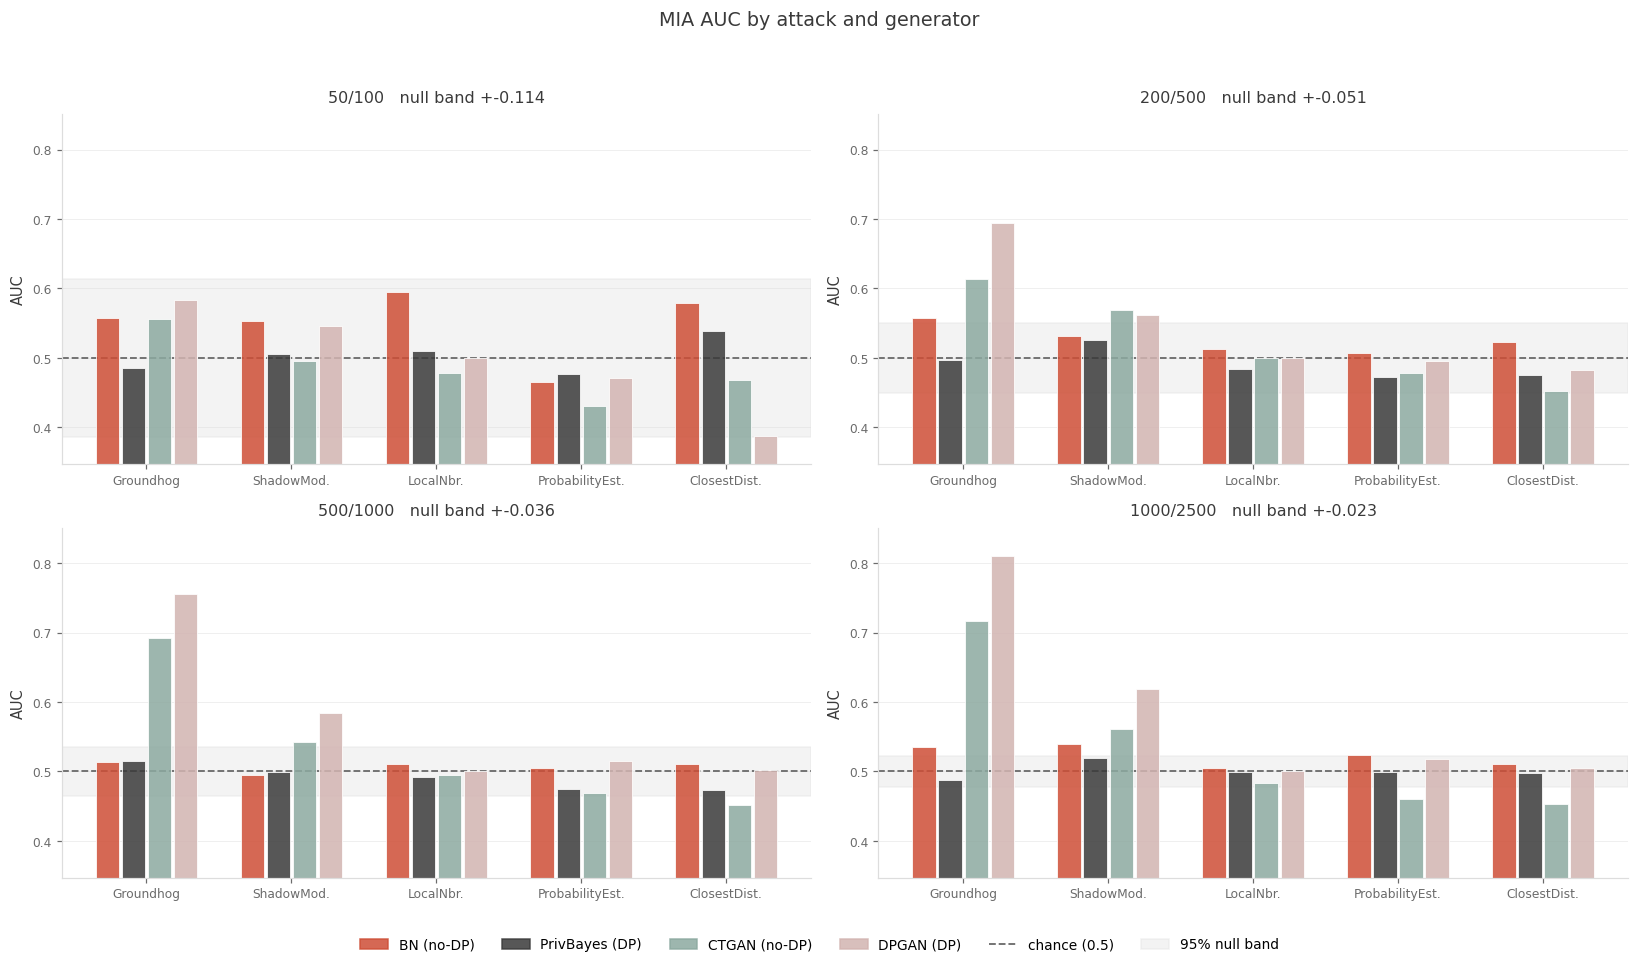

In [47]:
allauc = pd.concat([MW[f"{a}_{b}"].assign(stage=f"{a}/{b}") for a, b in AVAIL])
ylo, yhi = allauc.auc.min() - .04, allauc.auc.max() + .04

fig, axes = plt.subplots(2, 2, figsize=(15, 8.5), squeeze=False)
for k, (ntr, nte) in enumerate(AVAIL):
    ax = axes[k // 2][k % 2]
    st = f"{ntr}_{nte}"; hw = BANDS[st]
    piv = MW[st].pivot(index="attack", columns="generator", values="auc")
    attacks = [a for a in ATTACK_ORDER if a in piv.index]
    piv = piv.loc[attacks, [SHORT[g] for g in GENS]]
    x = np.arange(len(attacks)); width = .18
    offs = np.arange(len(GENS)) - (len(GENS) - 1) / 2
    ax.axhspan(.5 - hw, .5 + hw, color=GRID, alpha=.35, zorder=0)
    ax.axhline(.5, color=MUTED, ls="--", lw=1.2, zorder=1)
    for i, gen in enumerate(GENS):
        ax.bar(x + offs[i] * width, piv[SHORT[gen]].values, width * .9,
               color=GEN_COLOR[gen], alpha=.85, edgecolor="white", lw=.6, zorder=2,
               label=LABELS[gen] if k == 0 else None)
    ax.set_xticks(x); ax.set_xticklabels([SHORT_ATK[a] for a in attacks], fontsize=8.5)
    ax.set_ylim(ylo, yhi); ax.set_ylabel("AUC", fontsize=9.5, color=INK)
    ax.set_title(f"{ntr}/{nte}   null band +-{hw:.3f}", fontsize=10.5, color=INK, pad=8)
    tidy(ax); ax.grid(axis="y", color=GRID, lw=.6, alpha=.5)
handles = [plt.Rectangle((0, 0), 1, 1, color=GEN_COLOR[g], alpha=.85) for g in GENS] + \
          [Line2D([], [], color=MUTED, ls="--", lw=1.2), plt.Rectangle((0, 0), 1, 1, color=GRID, alpha=.35)]
fig.legend(handles=handles, labels=[LABELS[g] for g in GENS] + ["chance (0.5)", "95% null band"],
           loc="lower center", ncol=6, frameon=False, fontsize=9, bbox_to_anchor=(.5, -.02))
fig.suptitle("MIA AUC by attack and generator", fontsize=12.5, color=INK, y=1.0)
fig.tight_layout(rect=[0, .03, 1, .97])
fig.savefig(FIGURES_DIR / "auc_bar_chart.png", bbox_inches="tight")
plt.show()

## 5. Privacy-utility tradeoff

X: TSTR XGBoost AUC (mean over seeds). Y: mean MIA advantage (TP-FP) over the 5 attacks.

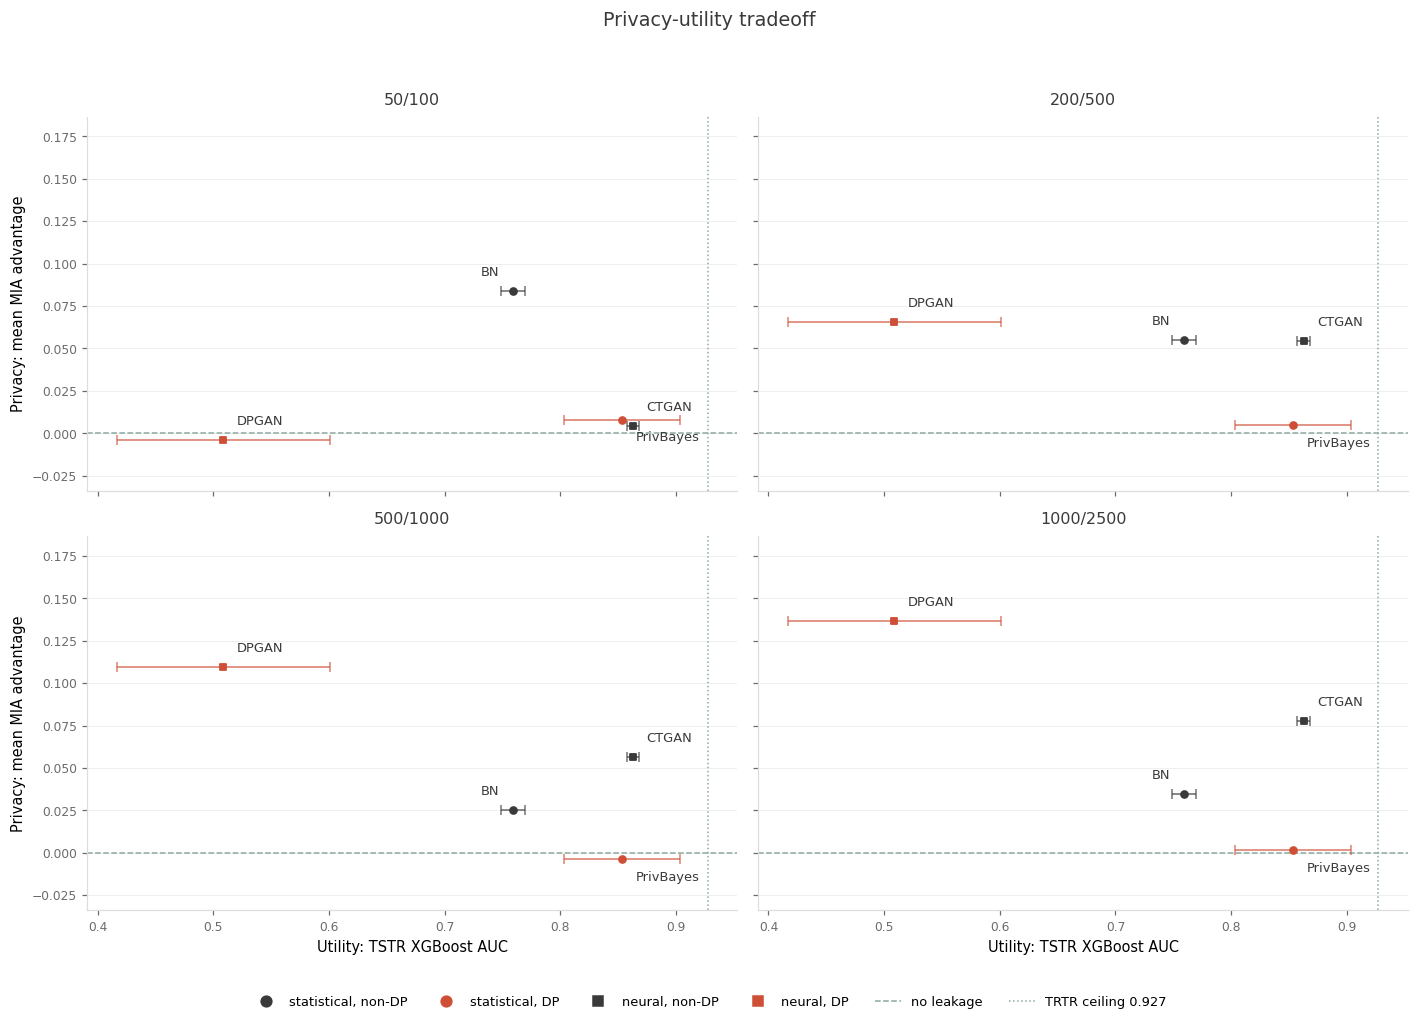

In [48]:
util = pd.read_csv(UTILITY_RESULTS)
adv_all = pd.concat([METRICS[f"{a}_{b}"].groupby("method").mia_advantage.mean()
                     .rename(f"{a}/{b}") for a, b in AVAIL], axis=1)
ylo2, yhi2 = adv_all.min().min() - .03, adv_all.max().max() + .05
gt = float(util.trtr_xgboost_auc_mean.dropna().iloc[0])

fig, axes = plt.subplots(2, 2, figsize=(13, 9), squeeze=False, sharex=True, sharey=True)
for k, (ntr, nte) in enumerate(AVAIL):
    ax = axes[k // 2][k % 2]
    adv = METRICS[f"{ntr}_{nte}"].groupby("method").mia_advantage.mean()
    ax.axhline(0, color=SAGE, ls="--", lw=1)
    ax.axvline(gt, color=SAGE, ls=":", lw=1)
    for gen in GENS:
        u = util[util.method == gen]
        if not len(u): continue
        xm, xs = float(u.tstr_xgboost_auc_mean.iloc[0]), float(u.tstr_xgboost_auc_std.iloc[0])
        dp, kind = METHOD_CONFIG[gen]["dp"], METHOD_CONFIG[gen]["kind"]
        col = ORANGE if dp else CHARCOAL       # DP orange, non-DP dark grey
        ax.errorbar(xm, adv[gen], xerr=xs, fmt="none", ecolor=col, elinewidth=1.1,
                    capsize=3, alpha=.7)
        # All markers filled: DP status is already carried by colour (orange vs charcoal,
        # which passes CVD separation), so the hollow/filled channel is redundant.
        ax.scatter(xm, adv[gen], s=20, marker="o" if kind == "statistical" else "s",
                   facecolor=col, edgecolor=col, lw=1.2, zorder=3)
        # PrivBayes and CTGAN sit almost on top of each other on the utility axis,
        # so their labels are pushed to opposite sides.
        dx, dy = {"privbayes": (9, -14), "ctgan": (9, 10),
                  "bayesian_network": (-9, 10), "dpgan": (9, 10)}.get(gen, (9, 9))
        ax.annotate(SHORT[gen], (xm, adv[gen]), textcoords="offset points",
                    xytext=(dx, dy), fontsize=8.5, color=INK,
                    ha="left" if dx > 0 else "right")
    ax.set_title(f"{ntr}/{nte}", fontsize=10.5, color=INK, pad=8)
    ax.set_ylim(ylo2, yhi2); tidy(ax); ax.grid(axis="y", color=GRID, lw=.6, alpha=.5)
    if k // 2 == 1: ax.set_xlabel("Utility: TSTR XGBoost AUC", fontsize=9.5)
    if k % 2 == 0: ax.set_ylabel("Privacy: mean MIA advantage", fontsize=9.5)
fig.legend(handles=[
    Line2D([], [], marker="o", ls="none", mfc=CHARCOAL, mec=CHARCOAL, ms=7, label="statistical, non-DP"),
    Line2D([], [], marker="o", ls="none", mfc=ORANGE, mec=ORANGE, ms=7, label="statistical, DP"),
    Line2D([], [], marker="s", ls="none", mfc=CHARCOAL, mec=CHARCOAL, ms=7, label="neural, non-DP"),
    Line2D([], [], marker="s", ls="none", mfc=ORANGE, mec=ORANGE, ms=7, label="neural, DP"),
    Line2D([], [], color=SAGE, ls="--", lw=1, label="no leakage"),
    Line2D([], [], color=SAGE, ls=":", lw=1, label=f"TRTR ceiling {gt:.3f}")],
    loc="lower center", ncol=6, frameon=False, fontsize=8.5, bbox_to_anchor=(.5, -.02))
fig.suptitle("Privacy-utility tradeoff", fontsize=12.5, color=INK, y=1.0)
fig.tight_layout(rect=[0, .03, 1, .97])
fig.savefig(FIGURES_DIR / "privacy_utility_tradeoff.png", bbox_inches="tight")
plt.show()

## 6. Formal epsilon sweep — DPGAN

**DRAFT — results land after the overnight run.** Every cell below no-ops with a
message until `results/eps_sweep/eps_sweep_summary.csv` exists.

Sections 1–5 vary the audit size at a fixed formal budget of ε = 1.0. This section holds
the audit size at 1000/2500 and varies ε instead, for DPGAN only, following
Chida et al. (MDAI 2024) — who swept PrivBayes at ε ∈ {0.1, 1, 10, 100} and audited with
TAPAS at exactly these counts. Applying that design to a DP-SGD **neural** generator is
the new part.

| | |
|---|---|
| ε swept | 0.1, 1.0, 10, 100 (ε = 1.0 reused from §1–5, not re-run) |
| audit | 1000/2500, 5-attack MIA battery, same background / target / attacks |
| utility | 5 seeds on the full 21,523-row split, TSTR/TRTR + 4 fidelity metrics |
| source | `scripts/run_eps_sweep.py`, `eps_sweep_{generate,evaluate,aggregate}.py` |

**Three caveats to carry into any reading of these panels.**

1. **σ is not a function of ε alone.** Opacus solves for the noise multiplier from
   (ε, δ, sample_rate, epochs), and synthcity derives δ and the sample rate from
   whatever frame it is handed. The audited 500-row world and the 21,523-row utility
   world therefore run at *different* σ **and different δ** at the same nominal ε —
   σ ≈ 11.7 vs ≈ 2.7 at ε = 1.0. The privacy panel and the utility panel are not
   measuring the same mechanism, and no amount of extra audit samples fixes that.
2. **δ moves with n and is not pinned** (`gan.py:590–591`, `dp_delta = 1/len(X)`).
   Left alone deliberately — pinning it would make this sweep a different mechanism
   from every other DPGAN number in the repo.
3. **`poisson_sampling=False`** (`gan.py:607`) while the accountant that produced σ
   assumes Poisson subsampling. The formal guarantee is an approximation throughout,
   so ε_eff exceeding ε would not by itself prove an implementation fault.

ε is reported as passed to synthcity. Opacus accounts under add/remove while this
threat model *swaps* one record for another, so the comparable replacement-relation
budget is 2ε — plotted as a second reference line, not folded into the axis.


In [49]:
# ---- load the sweep (no-op until the overnight run lands) ----
EPS_DIR = BENCH / "results" / "eps_sweep"
EPS_SUMMARY = EPS_DIR / "eps_sweep_summary.csv"
EPS_PER_ATTACK = EPS_DIR / "eps_sweep_privacy_per_attack.csv"

EPS = pd.read_csv(EPS_SUMMARY) if EPS_SUMMARY.exists() else None
EPS_ATK = pd.read_csv(EPS_PER_ATTACK) if EPS_PER_ATTACK.exists() else None

if EPS is None:
    print(f"not found: {EPS_SUMMARY.relative_to(BENCH)}\n"
          "Run, in order:\n"
          "  python benchmark_tapas/scripts/eps_sweep_sigma_check.py\n"
          "  python benchmark_tapas/scripts/eps_sweep_generate.py\n"
          "  python benchmark_tapas/scripts/eps_sweep_evaluate.py\n"
          "  python benchmark_tapas/scripts/run_eps_sweep.py        # ~13 h\n"
          "  python benchmark_tapas/scripts/eps_sweep_aggregate.py")
else:
    EPS = EPS.sort_values("formal_epsilon").reset_index(drop=True)
    done = EPS.worst_case_eff_eps_low.notna().sum() if "worst_case_eff_eps_low" in EPS else 0
    print(f"{len(EPS)} eps arms | {done} with privacy | "
          f"eps = {', '.join(f'{e:g}' for e in EPS.formal_epsilon)}")
    cols = [c for c in ["formal_epsilon", "sigma_audit", "sigma_utility",
                        "tstr_auc_xgb_mean", "KSComplement_mean",
                        "worst_case_eff_eps_low", "worst_case_eff_eps_high",
                        "worst_case_attack", "degenerate_pool"] if c in EPS.columns]
    display(EPS[cols].style.format(precision=3).hide(axis="index"))


4 eps arms | 4 with privacy | eps = 0.1, 1, 10, 100


formal_epsilon,sigma_audit,sigma_utility,tstr_auc_xgb_mean,KSComplement_mean,worst_case_eff_eps_low,worst_case_eff_eps_high,worst_case_attack,degenerate_pool
0.100,80.000,22.500,0.528,0.224,0.000,0.423,Groundhog,False
1.000,11.719,2.656,0.509,0.289,1.761,2.780,Groundhog,False
10.000,2.014,0.688,0.435,0.321,0.000,0.009,Groundhog,False
100.000,0.527,0.352,0.531,0.280,0.000,0.010,Groundhog,False


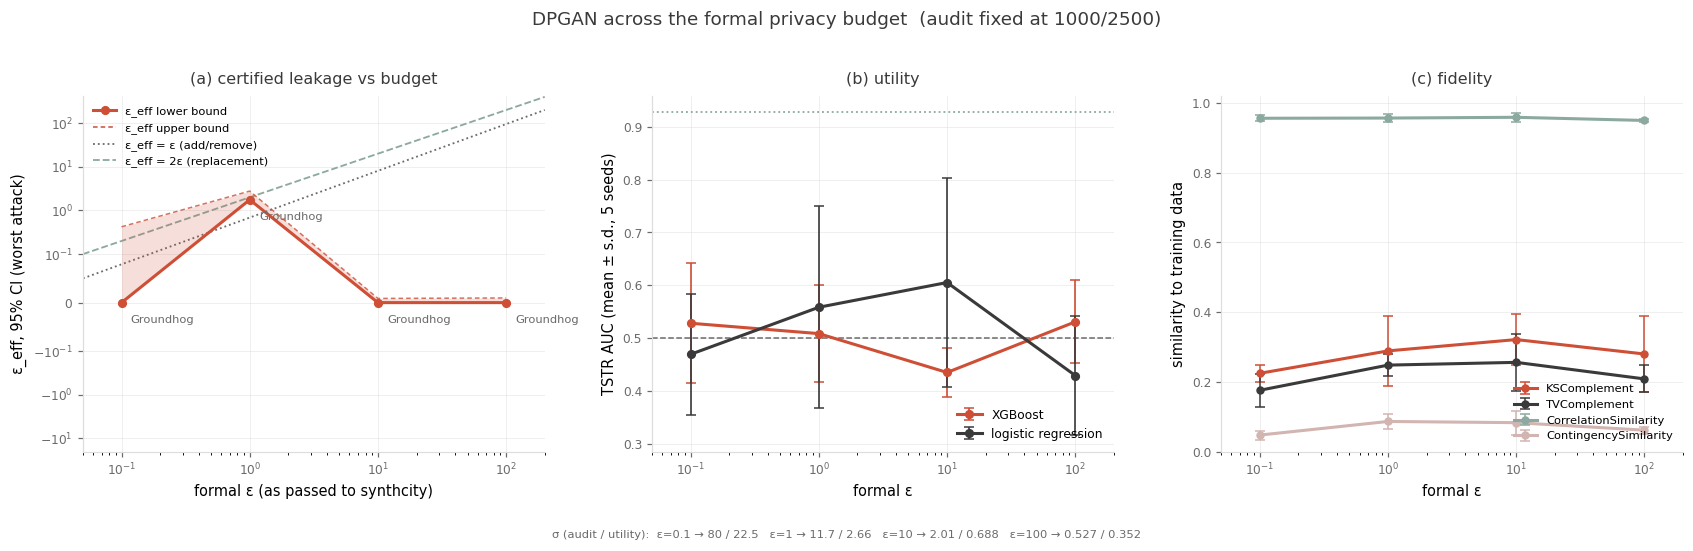

In [50]:
# ---- three panels against formal epsilon (log x throughout) ----
if EPS is None:
    print("skipped: run the sweep first (see the cell above)")
else:
    have = EPS.dropna(subset=["worst_case_eff_eps_low"]) if "worst_case_eff_eps_low" in EPS else EPS.iloc[:0]
    x = EPS.formal_epsilon.values
    lo, hi = x.min() / 2, x.max() * 2

    fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.5))

    # (a) certified leakage vs the budget that was paid for.
    ax = axes[0]
    ax.plot([lo, hi], [lo, hi], color=MUTED, ls=":", lw=1.2, zorder=1)
    ax.plot([lo, hi], [2 * lo, 2 * hi], color=SAGE, ls="--", lw=1.2, zorder=1)
    if len(have):
        xs = have.formal_epsilon.values
        elo, ehi = have.worst_case_eff_eps_low.values, have.worst_case_eff_eps_high.values
        ax.fill_between(xs, elo, ehi, color=ORANGE, alpha=.18, lw=0)
        ax.plot(xs, elo, color=ORANGE, lw=2, marker="o", ms=5, zorder=3)
        ax.plot(xs, ehi, color=ORANGE, lw=1, ls=(0, (3, 2)), alpha=.8, zorder=3)
        for _, r in have.iterrows():
            ax.annotate(str(r.worst_case_attack), (r.formal_epsilon, r.worst_case_eff_eps_low),
                        textcoords="offset points", xytext=(6, -13), fontsize=7.5, color=MUTED)
    ax.set_xscale("log"); ax.set_yscale("symlog", linthresh=0.1)
    ax.set_xlim(lo, hi)
    ax.set_xlabel("formal ε (as passed to synthcity)", fontsize=9.5)
    ax.set_ylabel("ε_eff, 95% CI (worst attack)", fontsize=9.5)
    ax.set_title("(a) certified leakage vs budget", fontsize=10.5, color=INK, pad=8)
    ax.legend(handles=[
        Line2D([], [], color=ORANGE, lw=2, marker="o", ms=5, label="ε_eff lower bound"),
        Line2D([], [], color=ORANGE, lw=1, ls=(0, (3, 2)), label="ε_eff upper bound"),
        Line2D([], [], color=MUTED, ls=":", lw=1.2, label="ε_eff = ε (add/remove)"),
        Line2D([], [], color=SAGE, ls="--", lw=1.2, label="ε_eff = 2ε (replacement)")],
        frameon=False, fontsize=7.5, loc="upper left")

    # (b) utility. TRTR is the same real-data ceiling at every eps.
    ax = axes[1]
    if "tstr_auc_xgb_mean" in EPS and EPS.tstr_auc_xgb_mean.notna().any():
        u = EPS.dropna(subset=["tstr_auc_xgb_mean"])
        if "trtr_auc_xgb" in u and u.trtr_auc_xgb.notna().any():
            ax.axhline(float(u.trtr_auc_xgb.dropna().iloc[0]), color=SAGE, ls=":", lw=1.2)
        ax.axhline(0.5, color=MUTED, ls="--", lw=1)
        for col, lbl, c in (("tstr_auc_xgb", "XGBoost", ORANGE),
                            ("tstr_auc_lr", "logistic regression", CHARCOAL)):
            if f"{col}_mean" not in u: continue
            m, s = u[f"{col}_mean"].values, u[f"{col}_std"].values
            ax.errorbar(u.formal_epsilon, m, yerr=s, color=c, lw=2, marker="o", ms=5,
                        capsize=3, elinewidth=1.1, label=lbl)
        ax.legend(frameon=False, fontsize=8, loc="lower right")
    ax.set_xscale("log"); ax.set_xlim(lo, hi)
    ax.set_xlabel("formal ε", fontsize=9.5)
    ax.set_ylabel("TSTR AUC (mean ± s.d., 5 seeds)", fontsize=9.5)
    ax.set_title("(b) utility", fontsize=10.5, color=INK, pad=8)

    # (c) fidelity. All four are similarity scores in [0,1], higher = better.
    ax = axes[2]
    FID = [("KSComplement", ORANGE), ("TVComplement", CHARCOAL),
           ("CorrelationSimilarity", SAGE), ("ContingencySimilarity", ROSE)]
    for name, c in FID:
        if f"{name}_mean" not in EPS or EPS[f"{name}_mean"].isna().all(): continue
        f = EPS.dropna(subset=[f"{name}_mean"])
        ax.errorbar(f.formal_epsilon, f[f"{name}_mean"], yerr=f[f"{name}_std"],
                    color=c, lw=2, marker="o", ms=4.5, capsize=3, elinewidth=1,
                    label=name)
    ax.set_xscale("log"); ax.set_xlim(lo, hi); ax.set_ylim(0, 1.02)
    ax.set_xlabel("formal ε", fontsize=9.5)
    ax.set_ylabel("similarity to training data", fontsize=9.5)
    ax.set_title("(c) fidelity", fontsize=10.5, color=INK, pad=8)
    ax.legend(frameon=False, fontsize=7.5, loc="lower right")

    for a in axes:
        tidy(a); a.grid(color=GRID, lw=.6, alpha=.5)
    # sigma is what eps actually buys; annotate rather than add a fourth panel.
    if "sigma_audit" in EPS:
        note = "σ (audit / utility):  " + "   ".join(
            f"ε={r.formal_epsilon:g} → {r.sigma_audit:.3g} / {r.sigma_utility:.3g}"
            for _, r in EPS.iterrows())
        fig.text(.5, -.045, note, ha="center", fontsize=7.5, color=MUTED)
    fig.suptitle("DPGAN across the formal privacy budget  (audit fixed at 1000/2500)",
                 fontsize=12, color=INK, y=1.02)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "eps_sweep_dpgan.png", bbox_inches="tight")
    plt.show()


In [51]:
# ---- per-attack detail: which attack sets the bound, and does that change with eps ----
if EPS_ATK is None:
    print("skipped: run the sweep first")
else:
    piv = (EPS_ATK.pivot_table(index="attack_short", columns="formal_epsilon",
                               values="eps_low_95")
           .reindex([a for a in ATTACK_ORDER if a in set(EPS_ATK.attack_short)]))
    print("ε_eff lower bound (95%) by attack x formal ε\n")
    print(piv.to_string(float_format=lambda v: f"{v:.3f}"))
    print("\nMIA advantage (TP - FP)\n")
    print(EPS_ATK.pivot_table(index="attack_short", columns="formal_epsilon",
                              values="mia_advantage")
          .reindex(piv.index).to_string(float_format=lambda v: f"{v:.3f}"))

    cols = [c for c in ["formal_epsilon", "attack_short", "auc", "tp", "fp", "tn", "fn",
                        "mia_advantage", "privacy_gain", "eps_low_95", "eps_high_95",
                        "eff_eps_tau", "eff_eps_tau_inverse"] if c in EPS_ATK.columns]
    display(EPS_ATK[cols].style.format(precision=3).hide(axis="index"))


ε_eff lower bound (95%) by attack x formal ε

formal_epsilon         0.1    1.0    10.0   100.0
attack_short                                     
Groundhog              0.000  1.761  0.000  0.000
ShadowModelling        0.000  0.241  0.000  0.000
LocalNeighbourhood     0.000  0.000  0.000  0.000
ProbabilityEstimation  0.000  0.000  0.000  0.000
ClosestDistance        0.000  0.000  0.000  0.000

MIA advantage (TP - FP)

formal_epsilon         0.1    1.0    10.0   100.0
attack_short                                     
Groundhog              0.066  0.452  0.041  0.133
ShadowModelling       -0.014  0.176  0.026  0.006
LocalNeighbourhood     0.000  0.000  0.000  0.000
ProbabilityEstimation  0.016  0.037  0.001  0.004
ClosestDistance        0.014  0.018  0.005  0.006


formal_epsilon,attack_short,auc,tp,fp,tn,fn,mia_advantage,privacy_gain,eps_low_95,eps_high_95,eff_eps_tau,eff_eps_tau_inverse
0.100,ClosestDistance,0.493,0.263,0.250,0.750,0.737,0.014,0.986,0.000,0.004,-2.139,0.000
0.100,Groundhog,0.549,0.514,0.449,0.551,0.486,0.066,0.934,0.000,0.423,0.570,0.000
0.100,LocalNeighbourhood,0.500,0.000,0.000,1.000,1.000,0.000,1.000,0.000,0.004,0.000,0.000
0.100,ProbabilityEstimation,0.519,0.298,0.282,0.718,0.702,0.016,0.984,0.000,0.009,-86.491,0.000
0.100,ShadowModelling,0.497,0.470,0.484,0.516,0.530,-0.014,1.014,0.000,0.004,0.180,0.000
1.000,ClosestDistance,0.504,0.457,0.438,0.562,0.543,0.018,0.982,0.000,0.006,nan,nan
1.000,Groundhog,0.811,0.720,0.268,0.732,0.280,0.452,0.548,1.761,2.780,nan,nan
1.000,LocalNeighbourhood,0.500,0.000,0.000,1.000,1.000,0.000,1.000,0.000,0.004,nan,nan
1.000,ProbabilityEstimation,0.517,0.578,0.542,0.458,0.422,0.037,0.963,0.000,0.013,nan,nan
1.000,ShadowModelling,0.619,0.588,0.412,0.588,0.412,0.176,0.824,0.241,0.572,nan,nan
